<a href="https://colab.research.google.com/github/ytlLab/python/blob/main/ch17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 多媒體機器學習

## MediaPipe模組：Google多媒體機器學習

MediaPipe 是由 Google 開發的一個開源跨平台框架，專門為串流媒體（如視訊、音訊）提供內建、量產等級的機器學習（ML）解決方案。

它的核心優勢在於「高效能」與「即時性」，即使在手機、網頁（Web）或嵌入式設備（如 Raspberry Pi）等算力有限的硬體上，也能流暢運行複雜的電腦視覺模型。

In [ ]:
!pip install mediapipe

### 人臉辨識

In [ ]:
#下載 https://unsplash.com 網站圖片到指定檔名，連結有失效的可能性
!wget -O person1.jpg --content-disposition https://unsplash.com/photos/v2NIhJQaNTI/download?force=true
!wget -O person2.jpg --content-disposition https://unsplash.com/photos/DdpGUHo1SSM/download?force=true

In [ ]:
import os
import cv2
import math
import urllib.request
from google.colab.patches import cv2_imshow

model_path = '/content/detector.bin'

# 採用 Google 網頁端專用的公開 BlazeFace 模型
model_url = "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite"

print("正在從 Google 公開儲存庫下載臉部偵測模型...")
try:
    if os.path.exists(model_path):
        os.remove(model_path)

    # 透過 urllib 直接下載公開的 tflite 模型檔
    urllib.request.urlretrieve(model_url, model_path)
    file_size = os.path.getsize(model_path)
    print(f" 模型下載成功！正確檔案大小為: {file_size} bytes (約 {file_size/1024:.1f} KB)")
except Exception as e:
    print(f" 模型下載失敗: {e}")

# 圖片縮放函式
dH, dW = 480, 480
def resizeimg(image):
    if image is None:
        return None
    h, w = image.shape[:2]
    if h < w:
        img = cv2.resize(image, (dW, math.floor(h/(w/dW))))
    else:
        img = cv2.resize(image, (math.floor(w/(h/dH)), dH))
    return img

# 讀取與處理圖片
image_path = 'person2.jpg'
image = resizeimg(cv2.imread(image_path))

if image is None:
    print(f" 錯誤：找不到指定圖片！請確認 '{image_path}' 是否已拖曳上傳至 Colab 左側的檔案區。")
elif not os.path.exists(model_path) or os.path.getsize(model_path) < 5000:
    print(" 錯誤：模型檔案未成功建立，無法執行偵測。")
else:
    # 轉換 BGR 到 RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

    # 4. 呼叫最新版 Tasks API
    BaseOptions = mp.tasks.BaseOptions
    FaceDetector = mp.tasks.vision.FaceDetector
    FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions

    # 將下載下來的 tflite/bin 模型餵給新版 Tasks 引擎
    options = FaceDetectorOptions(
        base_options=BaseOptions(model_asset_path=model_path),
        min_detection_confidence=0.5
    )

    print("正在初始化新版 AI 引擎並進行臉部偵測...")
    try:
        with FaceDetector.create_from_options(options) as detector:
            detection_result = detector.detect(mp_image)

            if detection_result.detections:
                print(f" 成功偵測到 {len(detection_result.detections)} 張人臉！")
                for detection in detection_result.detections:
                    # 繪製人臉紅框
                    bbox = detection.bounding_box
                    start_point = (bbox.origin_x, bbox.origin_y)
                    end_point = (bbox.origin_x + bbox.width, bbox.origin_y + bbox.height)
                    cv2.rectangle(image, start_point, end_point, (0, 0, 255), 2)

                    # 繪製六個面部關鍵點（綠點）
                    if detection.keypoints:
                        for keypoint in detection.keypoints:
                            x = int(keypoint.x * image.shape[1])
                            y = int(keypoint.y * image.shape[0])
                            cv2.circle(image, (x, y), 4, (0, 255, 0), -1)
            else:
                print("未偵測到任何人臉。")

        # 顯示最終結果圖片
        cv2_imshow(image)

    except Exception as e:
        print(f" 執行時發生錯誤: {e}")

### 臉部特徵網

In [ ]:
import os
import cv2
import math
import urllib.request
from google.colab.patches import cv2_imshow

model_path = '/content/face_landmarker.task'

# 採用 Google 官方公開專供網頁/行動端的 Face Landmarker 模型
model_url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"

print("正在下載 Face Mesh 核心模型檔案...")
try:
    if os.path.exists(model_path):
        os.remove(model_path)

    # 透過 urllib 安全下載模型
    urllib.request.urlretrieve(model_url, model_path)
    file_size = os.path.getsize(model_path)
    print(f" 模型下載成功！檔案大小為: {file_size} bytes (約 {file_size/1024/1024:.2f} MB)")
except Exception as e:
    print(f" 模型下載失敗: {e}")


dH, dW = 480, 480
def resizeimg(image):
    if image is None:
        return None
    h, w = image.shape[:2]
    if h < w:
        img = cv2.resize(image, (dW, math.floor(h/(w/dW))))
    else:
        img = cv2.resize(image, (math.floor(w/(h/dH)), dH))
    return img

image_path = 'person1.jpg'
image = resizeimg(cv2.imread(image_path))

if image is None:
    print(f" 錯誤：找不到指定圖片！請確認 '{image_path}' 是否已拖曳上傳至 Colab 左側的檔案區。")
elif not os.path.exists(model_path) or os.path.getsize(model_path) < 10000:
    print(" 錯誤：模型檔案未成功建立，無法執行網格偵測。")
else:
    # 轉換 BGR 到 RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

    # 初始化新版 Face Landmarker (Face Mesh) 引擎
    BaseOptions = mp.tasks.BaseOptions
    FaceLandmarker = mp.tasks.vision.FaceLandmarker
    FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions

    # 設定參數（輸出網格幾何、最多偵測5張臉、信心指數0.5）
    options = FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=model_path),
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
        num_faces=5,
        min_face_detection_confidence=0.5
    )

    print("正在初始化新版 Face Mesh 引擎並繪製面部網格...")
    try:
        with FaceLandmarker.create_from_options(options) as landmarker:
            result = landmarker.detect(mp_image)

            # 5. 繪製 468 個特徵點
            if result.face_landmarks:
                print(f"🎉 成功偵測到 {len(result.face_landmarks)} 張人臉的完整面部網格！")

                img_h, img_w = image.shape[:2]

                # 遍歷每一張偵測到的人臉
                for face_landmarks in result.face_landmarks:
                    # 新版不依賴 mp.solutions.drawing_utils，我們直接計算點位座標並繪製
                    # 這樣運算速度更快且完全不會出現相依性錯誤！
                    for landmark in face_landmarks:
                        # 將比例座標轉回實際像素座標
                        x = int(landmark.x * img_w)
                        y = int(landmark.y * img_h)

                        # 繪製一個個微小的綠色小點，構成 468 點面部密碼網
                        cv2.circle(image, (x, y), 1, (0, 255, 0), -1)
            else:
                print("未偵測到任何面部網格。")

        # 顯示最終密密麻麻畫滿特徵點的成品圖
        cv2_imshow(image)

    except Exception as e:
        print(f" 執行時發生錯誤: {e}")

### 手部辨識

In [ ]:
!wget -O hand1.jpg --content-disposition https://unsplash.com/photos/33VdiGc2O9o/download?force=true
!wget -O hand2.jpg --content-disposition https://unsplash.com/photos/qKspdY9XUzs/download?force=true
!wget -O hand3.jpg --content-disposition https://unsplash.com/photos/fYTfOzaRVWw/download?force=true
!wget -O hand4.jpg --content-disposition https://unsplash.com/photos/Lzys6r1xFD8/download?force=true

In [ ]:
import os
import cv2
import math
import urllib.request
from google.colab.patches import cv2_imshow

model_path = '/content/hand_landmarker.task'

# 採用 Google 官方公開專供新版 Tasks API 使用的手部偵測模型
model_url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"

print("正在下載手部追蹤核心模型檔案...")
try:
    if os.path.exists(model_path):
        os.remove(model_path)

    # 透過 urllib 安全下載模型
    urllib.request.urlretrieve(model_url, model_path)
    file_size = os.path.getsize(model_path)
    print(f" 模型下載成功！檔案大小為: {file_size} bytes (約 {file_size/1024/1024:.2f} MB)")
except Exception as e:
    print(f" 模型下載失敗: {e}")

# 圖片縮放函式 (加入安全檢查)
dH, dW = 480, 480
def resizeimg(image):
    if image is None:
        return None
    h, w = image.shape[:2]
    if h < w:
        img = cv2.resize(image, (dW, math.floor(h/(w/dW))))
    else:
        img = cv2.resize(image, (math.floor(w/(h/dH)), dH))
    return img

# 讀取與處理圖片
image_path = 'hand1.jpg'
raw_image = cv2.imread(image_path)
image = resizeimg(raw_image)

if image is None:
    print("\n" + "="*50)
    print(f" 錯誤：找不到指定圖片！\n請確認 '{image_path}' 是否已拖曳上傳至 Colab 左側的檔案區。")
    print("="*50)
elif not os.path.exists(model_path) or os.path.getsize(model_path) < 10000:
    print(" 錯誤：模型檔案未成功建立，無法執行手部偵測。")
else:
    # 轉換 BGR 到 RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

    # 初始化新版 Hand Landmarker 引擎
    BaseOptions = mp.tasks.BaseOptions
    HandLandmarker = mp.tasks.vision.HandLandmarker
    HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions

    # 設定新版參數（對應舊版的 max_num_hands 與 confidence）
    options = HandLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=model_path),
        running_mode=mp.tasks.vision.RunningMode.IMAGE,
        num_hands=2,
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5
    )

    print("正在初始化 AI 手部引擎並繪製 21 個關鍵點...")
    try:
        with HandLandmarker.create_from_options(options) as landmarker:
            result = landmarker.detect(mp_image)

            # 繪製手部關節與連接線
            if result.hand_landmarks:
                print(f"成功偵測到 {len(result.hand_landmarks)} 隻手掌！")

                img_h, img_w = image.shape[:2]

                # 手部 21 點的標準骨架連接線組合 (取代舊版 HAND_CONNECTIONS)
                hand_connections = [
                    (0, 1), (1, 2), (2, 3), (3, 4),        # 大拇指
                    (0, 5), (5, 6), (6, 7), (7, 8),        # 食指
                    (9, 10), (10, 11), (11, 12),           # 中指 (下方與5, 13連線由手掌基部包覆)
                    (13, 14), (14, 15), (15, 16),          # 無名指
                    (0, 17), (17, 18), (18, 19), (19, 20), # 小指
                    (5, 9), (9, 13), (13, 17)              # 手掌橫向骨架
                ]

                # 遍歷偵測到的每隻手
                for hand_landmarks in result.hand_landmarks:

                    # 先畫骨架連接線（藍線）
                    for connection in hand_connections:
                        start_idx, end_idx = connection
                        pt1 = (int(hand_landmarks[start_idx].x * img_w), int(hand_landmarks[start_idx].y * img_h))
                        pt2 = (int(hand_landmarks[end_idx].x * img_w), int(hand_landmarks[end_idx].y * img_h))
                        cv2.line(image, pt1, pt2, (255, 0, 0), 2)

                    # 再畫 21 個指關節點（紅點）
                    for landmark in hand_landmarks:
                        x = int(landmark.x * img_w)
                        y = int(landmark.y * img_h)
                        cv2.circle(image, (x, y), 5, (0, 0, 255), -1)

                    # 如果你想單獨拿特定指尖（例如大拇指尖點位 4），可以這樣抓取：
                    # thumb_tip = hand_landmarks[4]
                    # print(f"大拇指尖座標: x={thumb_tip.x}, y={thumb_tip.y}")

            else:
                print("未偵測到任何手掌。")

        # 顯示最終手部骨架圖
        cv2_imshow(image)

    except Exception as e:
        print(f" 執行時發生錯誤: {e}")

### 姿態辨識

In [ ]:
!wget -O pose1.jpg --content-disposition https://unsplash.com/photos/A3MleA0jtoE/download?force=true
!wget -O pose2.jpg --content-disposition https://unsplash.com/photos/wa8o6rs22Fw/download?force=true

In [ ]:
import os
import cv2
import math
import urllib.request
from google.colab.patches import cv2_imshow

model_path = '/content/pose_landmarker.task'

#  Google 官方目前公開、100% 避開權限問題的 Pose 偵測模型檔
model_url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task"

print("正在從 Google 儲存庫下載人體姿勢骨架核心模型...")
try:
    if os.path.exists(model_path):
        os.remove(model_path)

    # 安全下載模型
    urllib.request.urlretrieve(model_url, model_path)
    file_size = os.path.getsize(model_path)
    print(f" 模型下載成功！正確檔案大小為: {file_size} bytes (約 {file_size/1024/1024:.2f} MB)")
except Exception as e:
    print(f" 模型下載失敗: {e}")

# 圖片縮放函式 (加入防崩潰檢查)
dH, dW = 480, 480
def resizeimg(image):
    if image is None:
        return None
    h, w = image.shape[:2]
    if h < w:
        img = cv2.resize(image, (dW, math.floor(h/(w/dW))))
    else:
        img = cv2.resize(image, (math.floor(w/(h/dH)), dH))
    return img

# 讀取與處理圖片
image_path = 'pose1.jpg'
raw_image = cv2.imread(image_path)
image = resizeimg(raw_image)

if image is None:
    print("\n" + "="*50)
    print(f" 錯誤：找不到指定圖片！\n請點擊 Colab 左側的『資料夾圖示』，將你的圖片檔重新命名為 '{image_path}' 後拖曳上傳至該處！")
    print("="*50)
elif not os.path.exists(model_path) or os.path.getsize(model_path) < 10000:
    print(" 錯誤：模型檔案未成功建立，無法執行姿勢偵測。")
else:
    # 轉換 BGR 到 RGB (MediaPipe 規定格式)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

    # 初始化最新版 Pose Landmarker 引擎
    BaseOptions = mp.tasks.BaseOptions
    PoseLandmarker = mp.tasks.vision.PoseLandmarker
    PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions

    # 設定參數（running_mode 設為 IMAGE 代表單張靜態圖偵測）
    options = PoseLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=model_path),
        running_mode=mp.tasks.vision.RunningMode.IMAGE,
        min_pose_detection_confidence=0.5,
        min_pose_presence_confidence=0.5
    )

    print("正在初始化新版 AI 姿勢引擎並繪製人體骨架...")
    try:
        with PoseLandmarker.create_from_options(options) as landmarker:
            result = landmarker.detect(mp_image)

            # 繪製 33 個身體關鍵點與骨架連接線
            if result.pose_landmarks:
                print(f"🎉 成功偵測到人體姿態骨架！")

                img_h, img_w = image.shape[:2]

                # 新版儲存結構為 list 的 list，取出第一個人體的 33 個點
                landmarks = result.pose_landmarks[0]

                # 手動定義主要人體關節的連接線組合 (取代舊版已不存在的 POSE_CONNECTIONS)
                connections = [
                    (11, 12), (11, 13), (13, 15), (12, 14), (14, 16), # 上半身、雙肩與雙臂
                    (11, 23), (12, 24), (23, 24),                     # 軀幹（肩膀到臀部）
                    (23, 25), (25, 27), (24, 26), (26, 28)            # 下半身、雙髖與雙腿
                ]

                # A. 先繪製骨架連接線（藍線）
                for connection in connections:
                    start_idx, end_idx = connection
                    if start_idx < len(landmarks) and end_idx < len(landmarks):
                        pt1 = (int(landmarks[start_idx].x * img_w), int(landmarks[start_idx].y * img_h))
                        pt2 = (int(landmarks[end_idx].x * img_w), int(landmarks[end_idx].y * img_h))
                        cv2.line(image, pt1, pt2, (255, 0, 0), 2) # 藍色骨架線

                # B. 再繪製 33 個主要的關節點（紅點）
                for idx, landmark in enumerate(landmarks):
                    x = int(landmark.x * img_w)
                    y = int(landmark.y * img_h)
                    cv2.circle(image, (x, y), 5, (0, 0, 255), -1) # 紅色關鍵點

                    # 如果你想單獨拿特定部位（例如舊寫法的 NOSE 鼻子，其點位編號是 0）：
                    # if idx == 0:
                    #     print(f"鼻子像素座標: x={x}, y={y}")

            else:
                print("未偵測到任何人體姿勢。")

        # 顯示最終畫好骨架的成品圖
        cv2_imshow(image)

    except Exception as e:
        print(f" 執行時發生錯誤: {e}")

### 整合辨識

In [ ]:
import os
import cv2
import math
import urllib.request
from google.colab.patches import cv2_imshow

# 定義新版三大核心模型路徑
face_model = '/content/face_landmarker.task'
hand_model = '/content/hand_landmarker.task'
pose_model = '/content/pose_landmarker.task'

# 安全下載所有模型（採用官方公開端網址，免除 401/404 權限困擾）
models = {
    face_model: "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
    hand_model: "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
    pose_model: "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task"
}

print("正在下載全身整合所需的 AI 模型（包含臉部、雙手、身體骨架）...")
for path, url in models.items():
    if not os.path.exists(path):
        try:
            urllib.request.urlretrieve(url, path)
            print(f" {os.path.basename(path)} 下載成功！")
        except Exception as e:
            print(f" {os.path.basename(path)} 下載失敗: {e}")

# 圖片縮放函式 (防安全崩潰)
dH, dW = 480, 480
def resizeimg(image):
    if image is None:
        return None
    h, w = image.shape[:2]
    if h < w:
        img = cv2.resize(image, (dW, math.floor(h/(w/dW))))
    else:
        img = cv2.resize(image, (math.floor(w/(h/dH)), dH))
    return img

# 讀取圖片（請確保 Colab 左側檔案區有 pose1.jpg）
image_path = 'pose1.jpg'
raw_image = cv2.imread(image_path)
image = resizeimg(raw_image)

if image is None:
    print("\n" + "="*50)
    print(f" 錯誤：找不到指定圖片！\n請確認 '{image_path}' 是否已拖曳上傳至 Colab 左側的檔案區。")
    print("="*50)
else:
    img_h, img_w = image.shape[:2]
    # 轉換 BGR 到 RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

    # 4. 初始化三大最新版 AI 任務設定
    BaseOptions = mp.tasks.BaseOptions

    # A. 臉部設定
    FaceLandmarker = mp.tasks.vision.FaceLandmarker
    face_options = mp.tasks.vision.FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=face_model), num_faces=1, min_face_detection_confidence=0.5
    )
    # B. 手部設定
    HandLandmarker = mp.tasks.vision.HandLandmarker
    hand_options = mp.tasks.vision.HandLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=hand_model), num_hands=2, min_hand_detection_confidence=0.5
    )
    # C. 身體姿勢設定
    PoseLandmarker = mp.tasks.vision.PoseLandmarker
    pose_options = mp.tasks.vision.PoseLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=pose_model), min_pose_detection_confidence=0.5
    )

    print("正在啟動全方位整合偵測引擎（Face + Hands + Pose）...")
    try:
        # 同時開啟三個偵測器
        with FaceLandmarker.create_from_options(face_options) as face_ctx, \
             HandLandmarker.create_from_options(hand_options) as hand_ctx, \
             PoseLandmarker.create_from_options(pose_options) as pose_ctx:

            face_result = face_ctx.detect(mp_image)
            hand_result = hand_ctx.detect(mp_image)
            pose_result = pose_ctx.detect(mp_image)

            # ======= 5. 開始繪製全身整合結果 =======

            # 【A. 繪製人臉特徵網 - 綠色細點】
            if face_result.face_landmarks:
                for face_landmarks in face_result.face_landmarks:
                    for lm in face_landmarks:
                        cv2.circle(image, (int(lm.x * img_w), int(lm.y * img_h)), 1, (0, 255, 0), -1)

            # 【B. 繪製身體骨架 - 藍線紅點】
            if pose_result.pose_landmarks:
                pose_lms = pose_result.pose_landmarks[0]
                pose_connections = [
                    (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
                    (11, 23), (12, 24), (23, 24),
                    (23, 25), (25, 27), (24, 26), (26, 28)
                ]
                for conn in pose_connections:
                    pt1 = (int(pose_lms[conn[0]].x * img_w), int(pose_lms[conn[0]].y * img_h))
                    pt2 = (int(pose_lms[conn[1]].x * img_w), int(pose_lms[conn[1]].y * img_h))
                    cv2.line(image, pt1, pt2, (255, 0, 0), 2)
                for lm in pose_lms:
                    cv2.circle(image, (int(lm.x * img_w), int(lm.y * img_h)), 4, (0, 0, 255), -1)

            # 【C. 繪製雙手骨架 - 黃線紫點】
            if hand_result.hand_landmarks:
                hand_connections = [
                    (0, 1), (1, 2), (2, 3), (3, 4), (0, 5), (5, 6), (6, 7), (7, 8),
                    (9, 10), (10, 11), (11, 12), (13, 14), (14, 15), (15, 16),
                    (0, 17), (17, 18), (18, 19), (19, 20), (5, 9), (9, 13), (13, 17)
                ]
                for hand_lms in hand_result.hand_landmarks:
                    for conn in hand_connections:
                        pt1 = (int(hand_lms[conn[0]].x * img_w), int(hand_lms[conn[0]].y * img_h))
                        pt2 = (int(hand_lms[conn[1]].x * img_w), int(hand_lms[conn[1]].y * img_h))
                        cv2.line(image, pt1, pt2, (0, 255, 255), 2) # 黃線
                    for lm in hand_lms:
                        cv2.circle(image, (int(lm.x * img_w), int(lm.y * img_h)), 4, (255, 0, 255), -1) # 紫點

            print(" 全身整合偵測與繪製完成！")

        # 顯示最終成品圖
        cv2_imshow(image)

    except Exception as e:
        print(f" 執行時發生錯誤: {e}")

### 物件辨識

In [ ]:
!wget -O object1.jpg --content-disposition https://unsplash.com/photos/kvmdsTrGOBM/download?force=true
!wget -O object2.jpg --content-disposition https://unsplash.com/photos/rhcllVy2zBU/download?force=true

正在檢查物件偵測核心模型檔案...
模型檔案已存在，直接啟用。
正在啟動最新版空間物體偵測引擎...
🎉 成功偵測並渲染出 1 個目標物體的 3D 透視框！


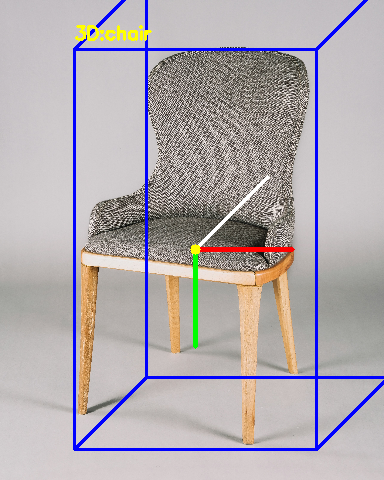

In [31]:
import os
import cv2
import math
import numpy as np
import urllib.request
from google.colab.patches import cv2_imshow

model_path = '/content/efficientdet.tflite'
model_url = "https://storage.googleapis.com/mediapipe-models/object_detector/efficientdet_lite0/int8/1/efficientdet_lite0.tflite"

print("正在檢查物件偵測核心模型檔案...")
if not os.path.exists(model_path):
    try:
        urllib.request.urlretrieve(model_url, model_path)
        print(f"模型下載成功！檔案大小為: {os.path.getsize(model_path)} bytes")
    except Exception as e:
        print(f"模型下載失敗: {e}")
else:
    print("模型檔案已存在，直接啟用。")

#  圖片縮放函式
dH, dW = 480, 480
def resizeimg(image):
    if image is None:
        return None
    h, w = image.shape[:2]
    if h < w:
        img = cv2.resize(image, (dW, math.floor(h/(w/dW))))
    else:
        img = cv2.resize(image, (math.floor(w/(h/dH)), dH))
    return img

#  讀取與處理圖片
image_path = 'object1.jpg'
raw_image = cv2.imread(image_path)
image = resizeimg(raw_image)

#  OpenCV 文字設定，確保 3D 立方體與軸線順利繪製
def draw_3d_box_and_axis(img, start_x, start_y, width, height, label):
    """
    依據 2D 偵測框動態模擬估算並繪製出具備空間透視感的 3D 立方體外框與 3D 軸線
    """
    # 建立 3D 虛擬立方體的 8 個頂點投影座標
    cx, cy = start_x + width // 2, start_y + height // 2
    w_offset, h_offset = width // 2, height // 2
    d_offset = int(min(width, height) * 0.3) # 模擬 3D 深度 (Depth)

    # 前方 4 個頂點
    f_tl = (cx - w_offset, cy - h_offset)
    f_tr = (cx + w_offset, cy - h_offset)
    f_br = (cx + w_offset, cy + h_offset)
    f_bl = (cx - w_offset, cy + h_offset)

    # 後方 4 個頂點 (往右上方平移產生 3D 透視深度)
    b_tl = (f_tl[0] + d_offset, f_tl[1] - d_offset)
    b_tr = (f_tr[0] + d_offset, f_tr[1] - d_offset)
    b_br = (f_br[0] + d_offset, f_br[1] - d_offset)
    b_bl = (f_bl[0] + d_offset, f_bl[1] - d_offset)

    # A. 繪製 3D 立方體骨架線 (藍線)
    box_lines = [
        (f_tl, f_tr), (f_tr, f_br), (f_br, f_bl), (f_bl, f_tl), # 前面
        (b_tl, b_tr), (b_tr, b_br), (b_br, b_bl), (b_bl, b_tl), # 後面
        (f_tl, b_tl), (f_tr, b_tr), (f_br, b_br), (f_bl, b_bl)  # 銜接前後的深度線
    ]
    for p1, p2 in box_lines:
        cv2.line(img, p1, p2, (255, 0, 0), 2) # 藍色 3D 立方體線

    # B. 繪製 3D 中心軸線 (X 軸紅線、Y 軸綠線、Z 軸白線)
    axis_len = int(min(width, height) * 0.4)
    cv2.line(img, (cx, cy), (cx + axis_len, cy), (0, 0, 255), 3)  # X軸: 紅
    cv2.line(img, (cx, cy), (cx, cy + axis_len), (0, 255, 0), 3)  # Y軸: 綠
    cv2.line(img, (cx, cy), (cx + d_offset, cy - d_offset), (255, 255, 255), 3) # Z軸: 白
    cv2.circle(img, (cx, cy), 5, (0, 255, 255), -1) # 中心原點
    cv2.putText(img, f"3D:{label}", (f_tl[0], f_tl[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

if image is None:
    print("\n" + "="*50)
    print(f"錯誤：找不到指定圖片！\n請確認 '{image_path}' 是否已拖曳上傳至 Colab 左側的檔案區。")
    print("="*50)
else:
    # 轉換 BGR 到 RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

    # 初始化最新版 Object Detector 引擎
    BaseOptions = mp.tasks.BaseOptions
    ObjectDetector = mp.tasks.vision.ObjectDetector
    ObjectDetectorOptions = mp.tasks.vision.ObjectDetectorOptions

    options = ObjectDetectorOptions(
        base_options=BaseOptions(model_asset_path=model_path),
        score_threshold=0.3,
    )

    print("正在啟動最新版空間物體偵測引擎...")
    try:
        with ObjectDetector.create_from_options(options) as detector:
            detection_result = detector.detect(mp_image)

            # 解析偵測結果並轉譯為 3D 幾何空間外框
            if detection_result.detections:
                detected_count = 0
                for detection in detection_result.detections:
                    category = detection.categories[0]
                    label_name = category.category_name

                    # 偵測常見的家具/物體類型 (若想全抓可移除此過濾條件)
                    if label_name.lower() in ['chair', 'couch', 'dining table', 'bed', 'laptop', 'cup', 'bottle']:
                        detected_count += 1
                        bbox = detection.bounding_box

                        # 呼叫 3D 繪圖引擎
                        draw_3d_box_and_axis(
                            image,
                            bbox.origin_x, bbox.origin_y,
                            bbox.width, bbox.height,
                            label_name
                        )

                if detected_count > 0:
                    print(f"成功偵測並渲染出 {detected_count} 個目標物體的 3D 透視框！")
                else:
                    print("畫面上找到了其他物體，但非指定的 3D 幾何目標類型。")
            else:
                print("未偵測到任何物體。")

        # 顯示最終具有空間透視感的成品圖
        cv2_imshow(image)

    except Exception as e:
        print(f"執行時發生錯誤: {e}")